<a href="https://colab.research.google.com/github/kerryjilak/TReND-CaMinA/blob/main/notebooks/Kenya26/03-04-AllenTutorial/project_templates/test.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Project** 1

### How well can you predict which brain region a neuron is in based on its activity?

This dataset surveyed visual responses across six different visual areas. One of the key questions we can ask is how the neural responses differ across these areas? There have been several studies that have looked at this, both using these data as well as other data. Two papers that motivated this study were published back-to-back: [Marshel, Garrett et al 2011](https://www.cell.com/neuron/fulltext/S0896-6273(11)01046-4?_returnURL=https%3A%2F%2Flinkinghub.elsevier.com%2Fretrieve%2Fpii%2FS0896627311010464%3Fshowall%3Dtrue) and [Andermann et al 2011](https://www.cell.com/neuron/fulltext/S0896-6273(11)01012-9?_returnURL=https%3A%2F%2Flinkinghub.elsevier.com%2Fretrieve%2Fpii%2FS0896627311010129%3Fshowall%3Dtrue). These two studies compared the tuning properties of neurons in different areas in the mouse visual cortex. They compared area responses using metrics such as orientation selectivity, preferred temporal frequency (TF), and preferred spatial frequency (SF).  Andermann et al particularly focused on the differences between areas AL and PM as these are thought to be parts of the ventral and dorsal visual streams, respectively. [see lecture slides X-Y]

Another notable study, [Kumar et al 2021](https://journals.plos.org/ploscompbiol/article?id=10.1371/journal.pcbi.1008548), uses the Allen Brain Observatory data to show that neurons can be parcellated into brain regions using short segments of natural movie responses or even spontaneous activity.

The question here is how accurately can you classify neurons into their respective brain regions based on their responses to the drifting grating stimulus?


In [1]:
# @title Run to initialize Allen Brain Observatory on Colab {display-mode: "form" }

# run only once per runtime/session, and only if running in colab
# the runtime will need to restxart after
%%capture
!apt install s3fs

!pip uninstall -y numpy pandas
!pip install git+https://github.com/AllenInstitute/AllenSDK@1bdca3ad884c3a5edea8236161424650603e6f29 "numpy == 1.26.4" "pandas == 2.3.0" "matplotlib > 3.8.0" "statsmodels >= 0.14.4"
import allensdk
print('allensdk imported successfully')

!mkdir -p /data/allen-brain-observatory/
!s3fs allen-brain-observatory /data/allen-brain-observatory/ -o public_bucket=1

import time
print("Runtime is now restarting...")
print("You can ignore the error message [Your session crashed for an unknown reason.]")
time.sleep(5)
exit()


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

Set up the AllenSDK and point it to the data manifest

In [2]:
from allensdk.core.brain_observatory_cache import BrainObservatoryCache

In [3]:
import platform, os, sys
platstring = platform.platform()

if ('amzn' in platstring) or ('google.colab' in sys.modules):
    # for AWS
    vc_cache_dir = '/data/allen-brain-observatory/visual-coding-2p'
else:
    # for local drive, different operating systems
    if ('Darwin' in platstring) or ('macOS' in platstring):
        # OS X
        data_root = "/Volumes/TReND2026/"
    elif 'Windows'  in platstring:
        # Windows (replace with the drive letter of USB drive)
        data_root = "E:/"
    else:
        # your own linux platform
        # EDIT location where you mounted hard drive
        data_root = "/media/$USERNAME/TReND2026/"

    # visual behavior cache directory
    vc_cache_dir = os.path.join(data_root, "allen-brain-observatory","visual-coding-2p")

boc = BrainObservatoryCache(manifest_file=os.path.join(vc_cache_dir, 'manifest.json'))

Get a dataframe of sessions in VISpm, layer 2/3 Cux2 when drifting gratings were shown

In [4]:
exps_pm = pd.DataFrame(boc.get_ophys_experiments(targeted_structures=['VISpm'],
                                              cre_lines=['Cux2-CreERT2'],
                                              imaging_depths=[175],
                                             stimuli=['drifting_gratings']))

Look at the data frame. How long is it?

In [5]:
exps_pm.head()

,id,imaging_depth,targeted_structure,cre_line,reporter_line,acquisition_age_days,experiment_container_id,session_type,donor_name,specimen_name,fail_eye_tracking
0,504115289,175,VISpm,Cux2-CreERT2,Ai93(TITL-GCaMP6f),124,511510817,three_session_A,222424,Cux2-CreERT2;Camk2a-tTA;Ai93-222424,True
1,502666254,175,VISpm,Cux2-CreERT2,Ai93(TITL-GCaMP6f),96,511510645,three_session_A,225039,Cux2-CreERT2;Camk2a-tTA;Ai93-225039,True
2,658854537,175,VISpm,Cux2-CreERT2,Ai93(TITL-GCaMP6f),110,658854535,three_session_A,360566,Cux2-CreERT2;Camk2a-tTA;Ai93-360566,False
3,512311673,175,VISpm,Cux2-CreERT2,Ai93(TITL-GCaMP6f),91,511976252,three_session_A,233214,Cux2-CreERT2;Camk2a-tTA;Ai93-233214,True
4,510859641,175,VISpm,Cux2-CreERT2,Ai93(TITL-GCaMP6f),82,511511083,three_session_A,233215,Cux2-CreERT2;Camk2a-tTA;Ai93-233215,False


In [6]:
len(exps_pm)

9

Now repeat this to get a dataframe of sessions in VISal, layer 2/3 Cux2 when drifting gratings were shown

In [7]:
exps_al = pd.DataFrame(boc.get_ophys_experiments(targeted_structures=['VISal'],
                                              cre_lines=['Cux2-CreERT2'],
                                              imaging_depths=[175],
                                             stimuli=['drifting_gratings']))

In [8]:
len(exps_al)

6

In tutorial 2 we wrote a function to compute the tuning curves for all the neurons in a single session. Copy and paste that here:

In [9]:
def compute_tuning(session_id):
    """
    Computes the 2D tuning array for all neurons in a given session
    for drifting gratings stimulus.

    Parameters
    ----------
    session_id : int
        The session id for one session.

    Returns
    -------
    dff : numpy.ndarray
        Delta F over F traces for all cells.
    stim_table : pandas.DataFrame
        Stimulus table for drifting gratings.
    trial_response : pandas.DataFrame
        Response per trial for all neurons.
    tuning_array : numpy.ndarray
        2D tuning array for all neurons, with dimensions (orientation, temporal_frequency, cell index).
    """
    #access data for the session
    data_set = boc.get_ophys_experiment_data(session_id)

    #get the DFF trace for all cells
    timestamps, dff = data_set.get_dff_traces()
    number_cells = dff.shape[0]
    print("Number of cells: ", number_cells)

    #get the stimulus table for the drifting gratings
    stim_table = data_set.get_stimulus_table('drifting_gratings')

    #get the orivals and tfvals
    all_ori = np.unique(stim_table.orientation)
    orivals = all_ori[np.isfinite(all_ori)]
    tfvals = np.unique(stim_table.temporal_frequency)
    tfvals = tfvals[np.isfinite(tfvals)]

    #compute response per trial for all neurons
    trial_response = pd.DataFrame(index=stim_table.index.values, columns=np.array(range(number_cells)).astype(str))

    for ind,row in stim_table.iterrows():
        for nc in range(number_cells):
            trial_response.loc[ind, str(nc)] = dff[nc,int(row.start):int(row.end)].mean()

    #calculate the response to the blanksweeps:
    blank_response = trial_response[np.isnan(stim_table.orientation)].mean()

    #compute 2D tuning array and subtract the blanksweep response
    tuning_array = np.empty((8,5,number_cells))
    for i,tf in enumerate(tfvals): #iterate across TF
        for j,ori in enumerate(orivals): #iterate across ori
            tuning_array[j,i,:] = trial_response[(stim_table.orientation==ori)&
                                                 (stim_table.temporal_frequency==tf)].mean() - blank_response

    return(dff, stim_table, trial_response, tuning_array)

Let's test this on the first session in our exps_pm list

In [10]:
session_id = exps_pm.id[0]
(dff, stim_table, trial_response, tuning_array) = compute_tuning(session_id)

Number of cells:  94


What's the shape of this array? Remind yourself what these axes are.

In [11]:
tuning_array.shape

(8, 5, 94)

Let's look at one neuron.

Text(0.5, 1.0, 'Cell 4')

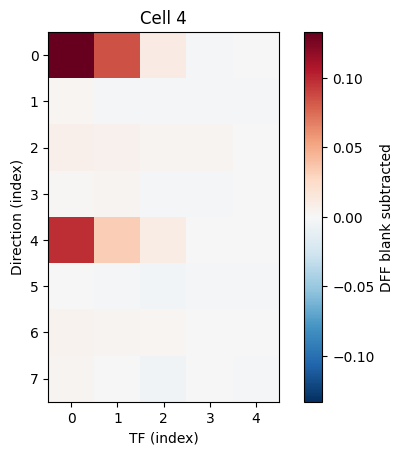

In [12]:
cell_id=4 #pick a cell index
plt.imshow(tuning_array[:,:,cell_id], cmap='RdBu_r', vmax=tuning_array[:,:,cell_id].max(), vmin=-1*tuning_array[:,:,cell_id].max())

plt.xlabel("TF (index)")
plt.ylabel("Direction (index)")

cbar = plt.colorbar()
cbar.set_label("DFF blank subtracted")
plt.title("Cell "+str(cell_id)) #Add a title so we know what the plot is of

We want to use this 2-dimensional tuning array to predict what brain region the neuron belonged to. This is easier if we can turn this 2D array into a 1D vector. To do that we'll use the function `np.reshape` to flatten our tuning_array.

In [13]:
ta_flatten = tuning_array.reshape(-1,tuning_array.shape[-1])

Now look at the shape of the resulting array. What are these dimensions?

In [14]:
ta_flatten.shape

(40, 94)

Let's plot the flattened tuning array for the same neuron as above.

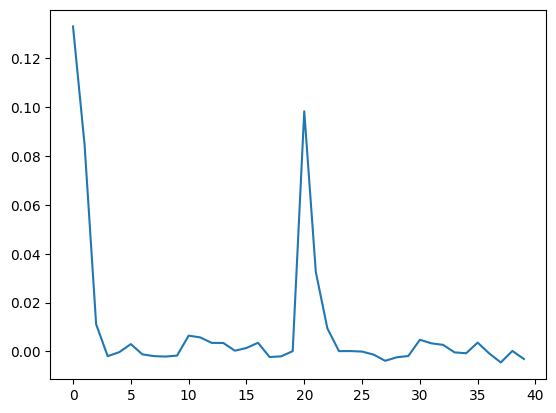

In [15]:
plt.plot(ta_flatten[:,cell_id])

And, for completeness, you can restore the original 2D tuning curve using the `np.reshape` function.

In [16]:
ta_reshape = ta_flatten[:,cell_id].reshape((8,5)) #this reshapes just our chosen neuron

Plot this to confirm we have the same original plot:

Text(0.5, 1.0, 'Cell 4')

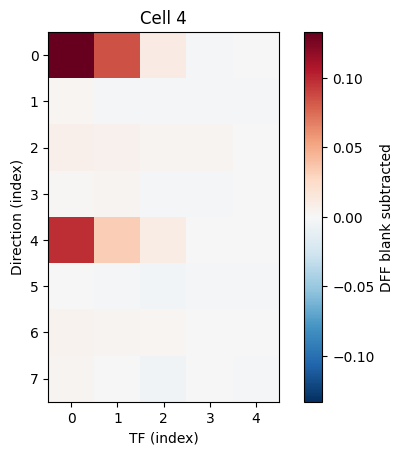

In [17]:
plt.imshow(ta_reshape[:,:], cmap='RdBu_r', vmax=ta_reshape.max(), vmin=-1*ta_reshape.max())

plt.xlabel("TF (index)")
plt.ylabel("Direction (index)")

cbar = plt.colorbar()
cbar.set_label("DFF blank subtracted")
plt.title("Cell "+str(cell_id)) #Add a title so we know what the plot is of



---



Okay, now that we've demonstrated what we want to do for all the neurons, let's
get to business!

Use function to compute 2D tuning array for all PM sessions. Flatten the tuning array from the session, and append the result to a growing list of tuning data.

In [18]:
#create an empty array to contain the results
tuning_pm = np.empty((40,0))

#for each session
for pmid in exps_pm.id:
    print("Session ID: ", pmid)
    #compute the 2D tuning array
    (dff, stim_table, trial_response, tuning_array) = compute_tuning(pmid)
    #flatten the array from (8,5,numbercells) to (40,numbercells)
    ta_flatten = tuning_array.reshape(-1,tuning_array.shape[-1])
    #append the result to the array for results
    tuning_pm = np.append(tuning_pm, ta_flatten, axis=1)

Session ID:  504115289
Number of cells:  94
Session ID:  502666254
Number of cells:  90
Session ID:  658854537
Number of cells:  112
Session ID:  512311673
Number of cells:  70
Session ID:  510859641
Number of cells:  124
Session ID:  503324629
Number of cells:  167
Session ID:  657914280
Number of cells:  84
Session ID:  502376461
Number of cells:  106
Session ID:  506773185
Number of cells:  101


What is the shape of your resulting array?

In [19]:
tuning_pm.shape

(40, 948)

Repeat this for the AL data.

In [20]:
tuning_al = np.empty((40,0))

for alid in exps_al.id:
    print("Session ID: ", alid)
    (dff, stim_table, trial_response, tuning_array) = compute_tuning(alid)
    ta_flatten = tuning_array.reshape(-1,tuning_array.shape[-1])
    tuning_al = np.append(tuning_al, ta_flatten, axis=1)

Session ID:  506773892
Number of cells:  76
Session ID:  557225279
Number of cells:  47
Session ID:  503412730
Number of cells:  119
Session ID:  502199136
Number of cells:  159
Session ID:  501876401
Number of cells:  181
Session ID:  501933264
Number of cells:  217


What is the shape of this array?

In [21]:
tuning_al.shape

(40, 799)

Note: if you want to save these two arrays, this would allow you to reload them without needing to recompute them in future session. Feel free to do that if you would like.



---
Now that we have our tuning arrays for all the neurons in PM and AL, we want to create a labels for each neuron. We'll label PM as 0 and AL as 1.



In [22]:
label = np.repeat(0,tuning_pm.shape[1]) #create a vector of 0's as long as the PM neurons
label = np.append(label, np.repeat(1,tuning_al.shape[1])) #append a vector of 1's as long as the AL neurons
len(label)

1747

Plot this to confirm it looks like you expect.

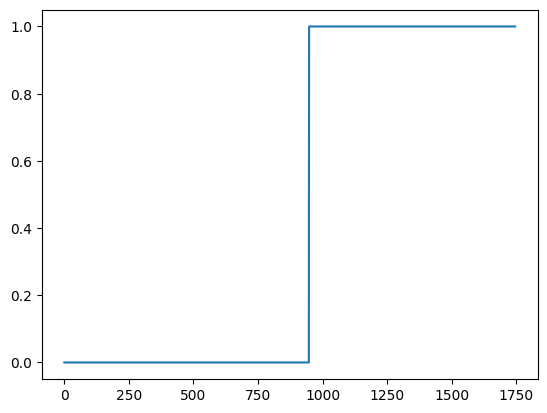

In [23]:
plt.plot(label)

Now let's append the two tuning arrays together. Do PM first and then AL to match the labels.

In [24]:
tuning = np.append(tuning_pm, tuning_al, axis=1)

In [25]:
tuning.shape

(40, 1747)

Notice that our label vector is as long as our tuning array.

The challenge in this project is to use classification methods to determine the correct label for a neuron based on its tuning. You can try a variety of methods and determine which ones work best, and how well you can differentiate these two regions (it won't be perfect!).

You will want to set up some hold out data to test your classification methods. So let's do that now. We will create a random list of integers to remove from these arrays. First, set a seed so that we create the same random selection if we rerun this code. Set the seed variable with your favorite number.

### Splitting the data

- Here we use a function in the scikit-learn model to split the dataset by first importing it

In [26]:
from sklearn.model_selection import train_test_split

Now get random numbers from the range of the number of neurons we have here. We'll select 200 neurons - but you can change this if you want to hold out more or less data.
This serves as an index into your tuning array and label vector.

In [27]:
# Transpose tuning so each row represents one neuron
# Shape becomes (number_of_neurons, 40)
X = tuning.T
y = label

# First split:
# 70% Training
# 30% Temporary (Validation + Test)

X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=15,
    stratify=y
)

# Second split:
# Split the remaining 30% equally into
# 15% Validation
# 15% Test

X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    random_state=15,
    stratify=y_temp
)

print("Training set:", X_train.shape)
print("Validation set:", X_val.shape)
print("Test set:", X_test.shape)

Training set: (1222, 40)
Validation set: (262, 40)
Test set: (263, 40)


In [28]:
print("\nTraining")
print(np.bincount(y_train))

print("\nValidation")
print(np.bincount(y_val))

print("\nTest")
print(np.bincount(y_test))


Training
[663 559]

Validation
[142 120]

Test
[143 120]


In [29]:
print("Training shape :", X_train.shape)
print("Validation shape:", X_val.shape)
print("Test shape :", X_test.shape)

print("\nNumber of features:", X_train.shape[1])

print("\nTraining labels")
print(np.bincount(y_train))

Training shape : (1222, 40)
Validation shape: (262, 40)
Test shape : (263, 40)

Number of features: 40

Training labels
[663 559]


In [30]:
from sklearn.preprocessing import StandardScaler

In [31]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_val_scaled = scaler.transform(X_val)

X_test_scaled = scaler.transform(X_test)

In [32]:
from sklearn.linear_model import LogisticRegression

In [33]:
log_reg = LogisticRegression(
    random_state=15,
    max_iter=1000
)

log_reg.fit(X_train_scaled, y_train)

LogisticRegression(max_iter=1000, random_state=15)

In [34]:
from sklearn.metrics import accuracy_score

val_predictions = log_reg.predict(X_val_scaled)

accuracy = accuracy_score(y_val, val_predictions)

print("Validation Accuracy:", accuracy)

Validation Accuracy: 0.5916030534351145


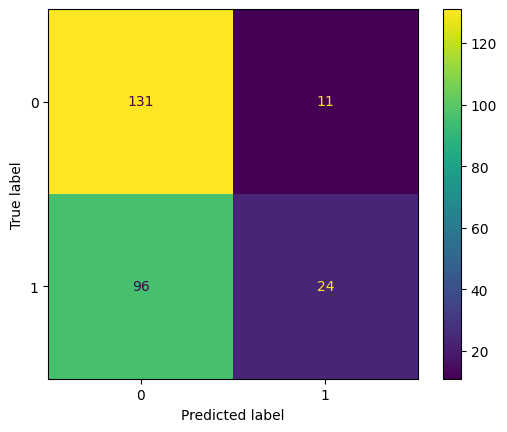

In [35]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

ConfusionMatrixDisplay.from_estimator(
    log_reg,
    X_val_scaled,
    y_val
)

plt.show()

In [36]:
from sklearn.metrics import classification_report

print(classification_report(y_val, val_predictions))

              precision    recall  f1-score   support

           0       0.58      0.92      0.71       142
           1       0.69      0.20      0.31       120

    accuracy                           0.59       262
   macro avg       0.63      0.56      0.51       262
weighted avg       0.63      0.59      0.53       262



In [37]:
coefficients = log_reg.coef_[0]

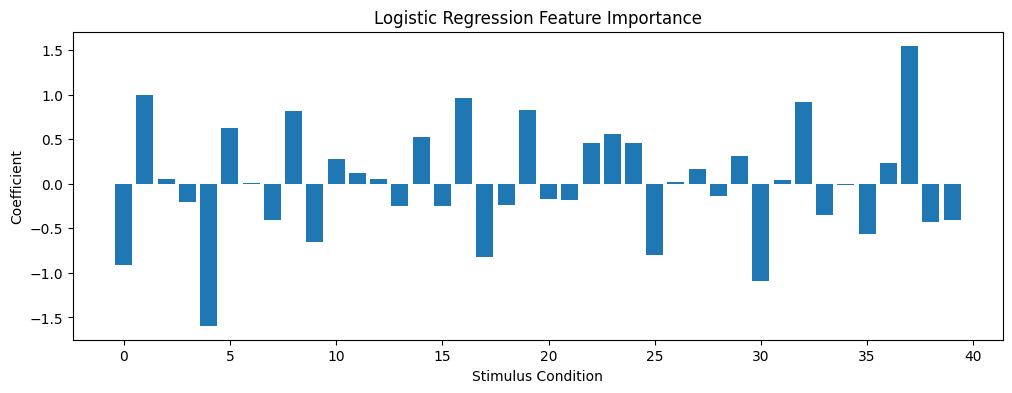

In [38]:
plt.figure(figsize=(12,4))

plt.bar(range(len(coefficients)), coefficients)

plt.xlabel("Stimulus Condition")

plt.ylabel("Coefficient")

plt.title("Logistic Regression Feature Importance")

plt.show()

From here, use your tuning_train and label_train to train classifier to best predict the brain region that each neuron is from. Sklearn has a number of classification methods that you can use and compare.


Other directions you can take this project in:


1.   If you've found some success in predicting AL and PM, see if you can compare other brain regions. Are there brain regions that are easier to differentiate than others?
2.   Here we used the tuning array for the response to drifting gratings to predict brain region. Could you use other aspects of the neurons' responses? For example, try using the dff traces during the spontaneous activity or the natural movie response. What other types of features could you look at?

